In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
# set professional color theme 
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

viridis_colors = cm.viridis(np.linspace(0,1,5))
primary_color = viridis_colors[0]
secondary_color = viridis_colors[1]
accent_color = viridis_colors[2]
danger_color ='#800000'
neutral_color = viridis_colors[4]
custom_palette = viridis_colors


In [3]:
df = pd.read_csv("C:\\Users\\pavitr\\OneDrive\\Documents\\supply_chain_project\\DataCoSupplyChainDataset.csv",encoding='latin-1')
df

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,02-03-2018 22.56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/15/2018 11:24,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 3:40,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 1:34,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 21:00,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/18/2016 20:18,Standard Class


In [4]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

<!-- # Exploratory Data Analysis (EDA) -->

In [5]:
# Overview
print('row,cols:',df.shape)
print('\ncolumns:')
print(df.columns.tolist())
print('\nNum duplitcate:',df.duplicated().sum())
print('\nMissing values (top 20):')
print(df.isna().sum().sort_values(ascending=False).head(20))

row,cols: (180519, 53)

columns:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Product 

<!-- # Data Cleaning -->

In [6]:
print(df[['order date (DateOrders)',
          'shipping date (DateOrders)']].isna().sum())

order date (DateOrders)       0
shipping date (DateOrders)    0
dtype: int64


In [7]:
# Cleaning the data 
column_to_drop = ['Product Description',
'Product Image',
'Customer Email',
'Customer Password',
'Customer Fname',
'Customer Lname',
'Customer Street',
'Customer Zipcode',
'Order Zipcode',
'Longitude',
'Latitude',
'Order Item Cardprod Id',
'Order Item Id',
'Order Item Discount',
'Order Item Product Price',
'Order Item Discount Rate',
'Order Item Quantity',
'Order Item Total',
'Category Id',
'Department Id',
'Order Id',
'Order Customer Id',
'Customer Id',
'Product Card Id',
'Product Category Id',
'Benefit per order', # identical to Order Profit Per Order
'Product Status', # have only one value,
'Customer City',
'Order City',
'Order Country',
'Order State',
'Customer State',
'Market' 
    ]

df = df.drop(columns=column_to_drop,errors='ignore')

df = df[df['Delivery Status'] != 'Shipping canceled']

for c in ['order date (DateOrders)','shipping date (DateOrders)']:
    df[c] = pd.to_datetime(df[c], errors='coerce',dayfirst=False)
    
    
df = df.dropna(
    subset=[
        'order date (DateOrders)',
        'shipping date (DateOrders)'
    ]
)


print('rows','cols',df.shape)
print('\nMissings values (top 5):')
print(df.isna().sum().sort_values(ascending=False).head(5))


rows cols (84581, 20)

Missings values (top 5):
Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Sales per customer               0
Delivery Status                  0
dtype: int64


In [8]:
newest_order_date = max(df['order date (DateOrders)'].dt.date)
oldest_order_date = min(df['order date (DateOrders)'].dt.date)
newest_shipping_date =max(df['order date (DateOrders)'].dt.date)
oldest_shippg_date = min(df['order date (DateOrders)'].dt.date)
print("this is newest order  date:-",newest_order_date)
print("this is oldest order date:-",oldest_order_date)
print("This is oldest shipping  date:-",oldest_shippg_date)
print("This is newest shipping date:-",newest_shipping_date)


this is newest order  date:- 2018-01-30
this is oldest order date:- 2015-01-13
This is oldest shipping  date:- 2015-01-13
This is newest shipping date:- 2018-01-30


In [9]:
total_sales = df['Sales'].round(1).sum()
print("Total Sales :-",total_sales)

Total Sales :- 17368336.1


In [10]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer Country,Customer Segment,Department Name,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Order Region,Order Status,Product Name,Product Price,shipping date (DateOrders),Shipping Mode
1,TRANSFER,5,4,311.359985,Late delivery,1,Sporting Goods,Puerto Rico,Consumer,Fitness,2018-01-13 12:27:00,-0.80,327.75,-249.089996,South Asia,PENDING,Smart watch,327.75,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,309.720001,Shipping on time,0,Sporting Goods,EE. UU.,Consumer,Fitness,2018-01-13 12:06:00,-0.80,327.75,-247.779999,South Asia,CLOSED,Smart watch,327.75,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,304.809998,Advance shipping,0,Sporting Goods,EE. UU.,Home Office,Fitness,2018-01-13 11:45:00,0.08,327.75,22.860001,Oceania,COMPLETE,Smart watch,327.75,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,298.250000,Advance shipping,0,Sporting Goods,Puerto Rico,Corporate,Fitness,2018-01-13 11:24:00,0.45,327.75,134.210007,Oceania,PENDING_PAYMENT,Smart watch,327.75,2018-01-15 11:24:00,Standard Class
6,DEBIT,2,1,288.420013,Late delivery,1,Sporting Goods,Puerto Rico,Home Office,Fitness,2018-01-13 10:42:00,0.33,327.75,95.180000,Eastern Asia,COMPLETE,Smart watch,327.75,2018-01-15 10:42:00,First Class


In [11]:
for col in df.columns:
    if df[col].nunique() < 10:
        print(f"\n {col} , value counts:")
        print(df[col].value_counts())


 Type , value counts:
Type
DEBIT       34274
PAYMENT     20419
TRANSFER    20380
CASH         9508
Name: count, dtype: int64

 Days for shipping (real) , value counts:
Days for shipping (real)
2    29434
3    13586
4    12766
5    12005
6    11171
0     3058
1     2561
Name: count, dtype: int64

 Days for shipment (scheduled) , value counts:
Days for shipment (scheduled)
4    48516
2    15908
1    14538
0     5619
Name: count, dtype: int64

 Delivery Status , value counts:
Delivery Status
Late delivery       46562
Advance shipping    21409
Shipping on time    16610
Name: count, dtype: int64

 Late_delivery_risk , value counts:
Late_delivery_risk
1    46562
0    38019
Name: count, dtype: int64

 Customer Country , value counts:
Customer Country
EE. UU.        52061
Puerto Rico    32520
Name: count, dtype: int64

 Customer Segment , value counts:
Customer Segment
Consumer       44071
Corporate      25481
Home Office    15029
Name: count, dtype: int64

 Order Status , value counts:
Order

In [12]:
df['Order Processing Time'] = (df['shipping date (DateOrders)']- df['order date (DateOrders)']).dt.days
df['Delay'] = df['Order Processing Time'] - df['Days for shipment (scheduled)']
df['Is_Delayed'] = df['Delay'] > 0 
df['Order_month'] = df['order date (DateOrders)'].dt.month
df['Order_day'] = df['order date (DateOrders)'].dt.day_name()
df['Order_hour'] = df['order date (DateOrders)'].dt.hour
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Late_delivery_risk,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Product Price,shipping date (DateOrders),Order Processing Time,Delay,Order_month,Order_hour
count,84581.000000,84581.000000,84581.000000,84581.000000,84581,84581.000000,84581.000000,84581.000000,84581.000000,84581,84581.000000,84581.000000,84581.000000,84581.000000
mean,3.314007,2.842459,184.544353,0.550502,2016-06-17 07:08:56.392097280,0.120642,205.332455,22.351374,142.452568,2016-06-20 14:45:20.414513920,3.283728,0.441269,6.252137,11.500278
min,0.000000,0.000000,7.490000,0.000000,2015-01-13 00:20:00,-2.750000,9.990000,-3442.500000,9.990000,2015-01-14 22:40:00,0.000000,-2.000000,1.000000,0.000000
25%,2.000000,2.000000,104.489998,0.000000,2015-09-24 05:56:00,0.080000,119.980003,6.930000,50.000000,2015-09-27 18:53:00,2.000000,-1.000000,3.000000,5.000000
50%,3.000000,4.000000,165.960007,1.000000,2016-06-17 20:27:00,0.270000,199.919998,31.590000,59.990002,2016-06-21 14:08:00,3.000000,1.000000,6.000000,11.000000
75%,5.000000,4.000000,248.979996,1.000000,2017-02-27 03:06:00,0.360000,299.950012,65.489998,199.990005,2017-02-28 19:34:00,5.000000,1.000000,9.000000,18.000000
max,6.000000,4.000000,1500.000000,1.000000,2018-01-30 08:24:00,0.500000,1500.000000,720.299988,1500.000000,2018-01-31 23:18:00,6.000000,4.000000,12.000000,23.000000
std,1.613468,1.422083,122.076543,0.497446,NaN,0.467371,134.362787,104.933901,142.280002,NaN,1.665164,1.470284,3.408443,6.922693


In [13]:
df['Is_Delayed'].value_counts()

Is_Delayed
True     44001
False    40580
Name: count, dtype: int64

In [14]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Name', 'Customer Country', 'Customer Segment',
       'Department Name', 'order date (DateOrders)', 'Order Item Profit Ratio',
       'Sales', 'Order Profit Per Order', 'Order Region', 'Order Status',
       'Product Name', 'Product Price', 'shipping date (DateOrders)',
       'Shipping Mode', 'Order Processing Time', 'Delay', 'Is_Delayed',
       'Order_month', 'Order_day', 'Order_hour'],
      dtype='object')

In [15]:
df['profitability flag'] = np.where (df['Order Profit Per Order'] > 0,'Profit',np.where(df['Order Profit Per Order'] < 0 ,'Loss','Break-even'))
df['profitability flag'].value_counts()

profitability flag
Profit        68139
Loss          15855
Break-even      587
Name: count, dtype: int64

In [16]:
df['profitability flag'].value_counts(normalize=True)

profitability flag
Profit        0.805606
Loss          0.187453
Break-even    0.006940
Name: proportion, dtype: float64

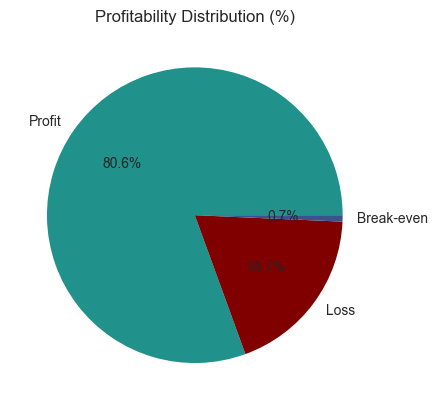

In [17]:
profit_counts = df['profitability flag'].value_counts(normalize=True) * 100
profit_counts.plot(kind= 'pie',autopct='%1.1f%%',colors=[accent_color,danger_color,secondary_color])
plt.ylabel('')
plt.title('Profitability Distribution (%)')
plt.show()

In [18]:
def format_func(value):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'{value:.0f} $'


delayed_df = df[df['Delay'] > 0]
metrics = {}
metrics ['Total Orders'] = len(df)
metrics['Late Deliveries'] = len(delayed_df)
metrics['90% Delay (days)'] = delayed_df['Delay'].quantile(0.90)
metrics['On  time Delivery % '] = (1-float(metrics['Late Deliveries']) / metrics['Total Orders'] * 100)
metrics['Late Deliveries % '] = metrics['Late Deliveries'] / metrics['Total Orders'] * 100 
metrics['Total Profit'] = format_func(df.loc[df['Order Profit Per Order'] >0 ,'Order Profit Per Order'].sum())
metrics['Total  Loss  due  to delays'] =  format_func(df.loc[df['Delay'] >0 ,'Order Profit Per Order'].sum())

print('\n--- Business  KPI  ---\n')
for  k,v  in metrics.items():
    if isinstance(v,float):
         print(f"{k}: {v:.2f}")
    else:
        print(f"{k} : {v}")






--- Business  KPI  ---

Total Orders : 84581
Late Deliveries : 44001
90% Delay (days): 3.00
On  time Delivery % : -51.02
Late Deliveries % : 52.02
Total Profit : 3.7M $
Total  Loss  due  to delays : 987.7K $


<!-- # Profitability  VS Delivery Time Analysis -->

In [19]:
Profit_metrics = (
    df.groupby('Delay')['Order Profit Per Order']
    .agg(mean_profit = 'mean',
         total_profit = 'sum',
         order_count ='count')
        .reset_index()
)
Profit_metrics

,Delay,mean_profit,total_profit,order_count
0,-2,24.785917,275495.470242,11115
1,-1,20.789134,214003.350087,10294
2,0,21.558735,413302.500308,19171
3,1,22.924978,615054.240972,26829
4,2,22.115320,250610.809823,11332
5,3,21.228307,63812.289854,3006
6,4,20.544432,58222.919934,2834


In [20]:
delay_distribution = (
    df['Delay']
    .value_counts(normalize=True)
    .sort_index() * 100
).reset_index()
delay_distribution

,Delay,proportion
0,-2,13.141249
1,-1,12.170582
2,0,22.665847
3,1,31.719890
4,2,13.397808
5,3,3.553990
6,4,3.350634



Profit Metrics by Delay Day:


,Delay,mean_profit,total_profit,order_count
0,-2,24.8,275495.5,11115
1,-1,20.8,214003.4,10294
2,0,21.6,413302.5,19171
3,1,22.9,615054.2,26829
4,2,22.1,250610.8,11332
5,3,21.2,63812.3,3006
6,4,20.5,58222.9,2834



Delay Distribution (%):


,Delay_Days,percentage
0,-2,13.141249
1,-1,12.170582
2,0,22.665847
3,1,31.719890
4,2,13.397808
5,3,3.553990
6,4,3.350634


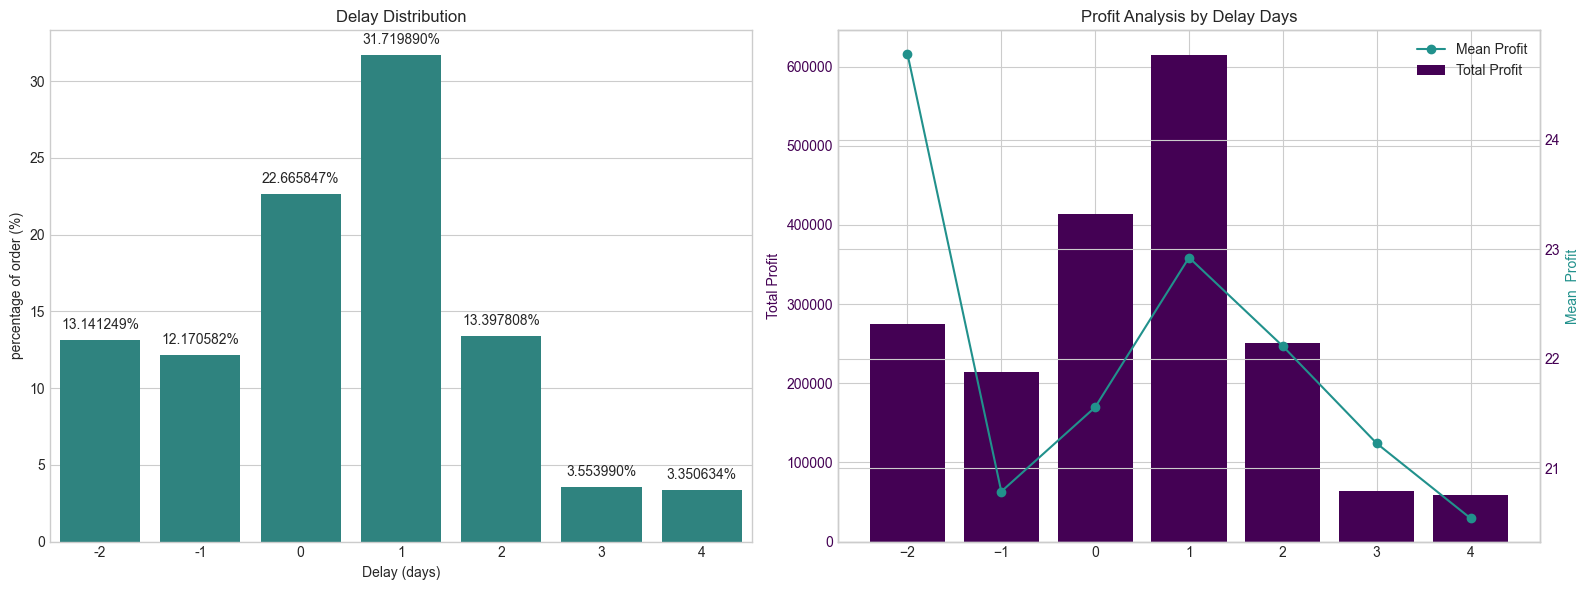

In [21]:
delay_distribution.columns = ['Delay_Days','percentage']

print('\nProfit Metrics by Delay Day:')
display(Profit_metrics.round(1))

print('\nDelay Distribution (%):')
display(delay_distribution)

fig,(ax1,ax2) = plt.subplots(1,2,figsize=(16,6))

# First  subplot: Delay Distribution
sns.barplot(x='Delay_Days',y='percentage',data=delay_distribution,color=accent_color,ax=ax1)
ax1.set_title('Delay Distribution')

ax1.set_xlabel('Delay (days)')
ax1.set_ylabel('percentage of order (%)')

for  bar in ax1.patches:
    height = bar.get_height()
    ax1.text(bar.get_x() +  bar.get_width()/2,height + 0.5 ,f'{height:1f}%' , ha='center', va= 'bottom')


# Second subplot: Profit Analysis by Delay  Days
ax2.set_ylabel('Total Profit',color=primary_color)
ax2.bar(Profit_metrics['Delay'],Profit_metrics['total_profit'],color=primary_color,label='Total Profit')
ax2.tick_params(axis='y',labelcolor=primary_color)

ax3 = ax2.twinx()

ax3.set_xlabel("Delay Days")
ax3.set_ylabel('Mean  Profit',color= accent_color)
ax3.plot(Profit_metrics['Delay'],Profit_metrics['mean_profit'],marker='o',label='Mean Profit',color= accent_color)
ax3.tick_params(axis='y',labelcolor=primary_color)

# format total profit axis to K $ M $
def format_func(value):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'{value:.0f} $'

ax2.yaxis.set_minor_formatter(ticker.FuncFormatter(format_func))
ax3.set_title("Profit Analysis by Delay Days")

lines,labels = ax3.get_legend_handles_labels()
lines2,labels2 = ax2.get_legend_handles_labels()
ax3.legend(lines + lines2,labels +labels2,loc='upper right') 

plt.tight_layout()
plt.show()

<!-- # Bottleneck Detection -->

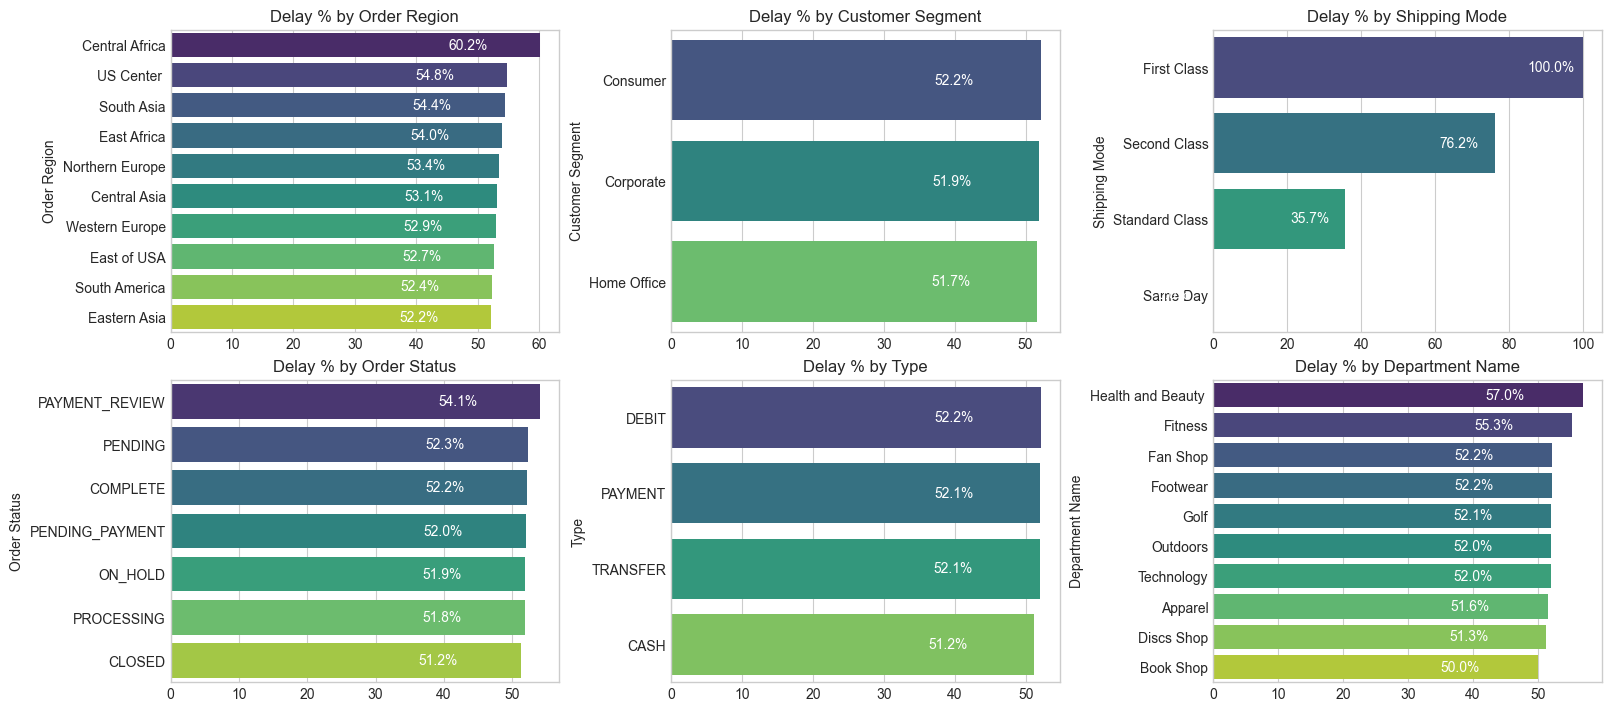

In [22]:
def compute_delay_pct_by_category(category):
    cat_df = df.groupby(category).agg(
    total_orders=('Delay', 'count'),
    late_orders=('Is_Delayed', 'sum')
    ).reset_index()

    cat_df['delay_pct'] = cat_df['late_orders'] / cat_df['total_orders'] * 100
    cat_df = cat_df.sort_values('delay_pct', ascending=False).head(10)
    return cat_df

categories = ['Order Region', 'Customer Segment', 'Shipping Mode', 'Order Status', 'Type', 'Department Name']
fig, axes = plt.subplots(2, 3, figsize=(16, 7), constrained_layout=True)
axes = axes. flatten()
for ax, category in zip(axes, categories):
    cat_df = compute_delay_pct_by_category(category)
    sns.barplot(
    data=cat_df,
    x='delay_pct',
    y=category,
    ax=ax,
    palette='viridis'
    )
    ax.set_title(f'Delay % by {category}')
    ax.set_xlabel('')
    ax.set_ylabel(category)
    for i, row in cat_df.reset_index().iterrows():
        ax.text(row['delay_pct'] - 15, i, f"{row['delay_pct'] :.1f}%", va='center', fontsize=10, color = 'white')

plt.show()

<!-- # Root Cause Analysis -->

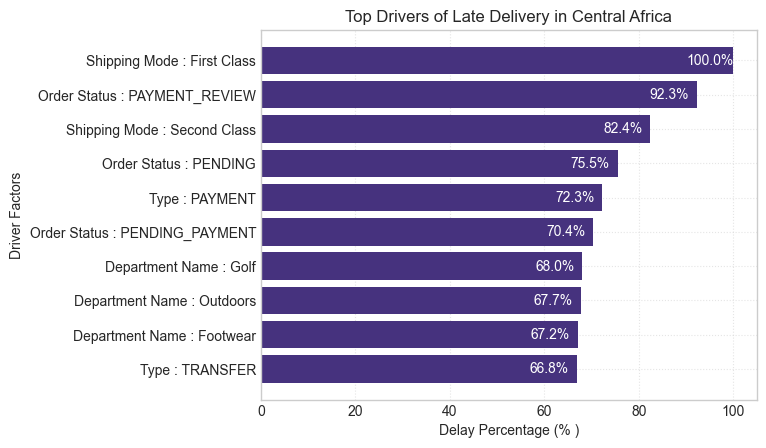

In [23]:
# Top drivers of late delivery by region

def top_drivers_for_region(region):
    df_region = df[df['Order Region'] == region].copy()

    drivers = ['Shipping Mode', 'Customer Segment', 'Department Name', 'Type', 'Order Status']
    all_factors = []
    for factor in drivers:
        temp = (
            df_region.groupby(factor)
            .agg (
                total_orders=('Delay', 'count'),
                late_orders=('Is_Delayed','sum'),
                avg_delay=('Delay', 'mean')
            )
            .reset_index()
        )

        temp['delay_pct'] = temp['late_orders'] / temp['total_orders'] * 100
        temp['Driver'] = factor
        temp['Factor_Level'] = factor + " : " + temp[factor].astype(str)
        
        all_factors.append(temp[['Driver', 'Factor_Level', 'delay_pct', 'avg_delay', 'total_orders']])
# Combine all drivers
    final_df = pd.concat(all_factors)
# Top 10 drivers
    top_factors = final_df.sort_values('delay_pct', ascending=False).head(10)
    plt.figure()

    bars = plt.barh(top_factors['Factor_Level'], top_factors['delay_pct'])
    plt.xlabel("Delay Percentage (% )")

    plt.ylabel("Driver Factors")
    plt.title(f"Top Drivers of Late Delivery in {region}")
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.gca().invert_yaxis()
    for bar in bars:
        width = bar.get_width()
        plt.text(width - 10, bar.get_y() + bar.get_height()/2,
                f"{width :.1f}%",
                va='center', fontsize = 10, color = 'white')

    plt.show()

top_drivers_for_region('Central Africa')

In [24]:
# Delay % by Month, Day of Week, Hour

delay_by_month = (df.groupby('Order_month') ['Is_Delayed'].mean().reset_index())

delay_by_month['delay_pct'] = delay_by_month['Is_Delayed'] * 100

delay_by_day = (df.groupby('Order_day') ['Is_Delayed'].mean().reset_index())

delay_by_day['delay_pct'] = delay_by_day['Is_Delayed'] * 100

delay_by_hour = (df.groupby('Order_hour') ['Is_Delayed'].mean ().reset_index())
delay_by_hour['delay_pct'] = delay_by_hour['Is_Delayed'] * 100

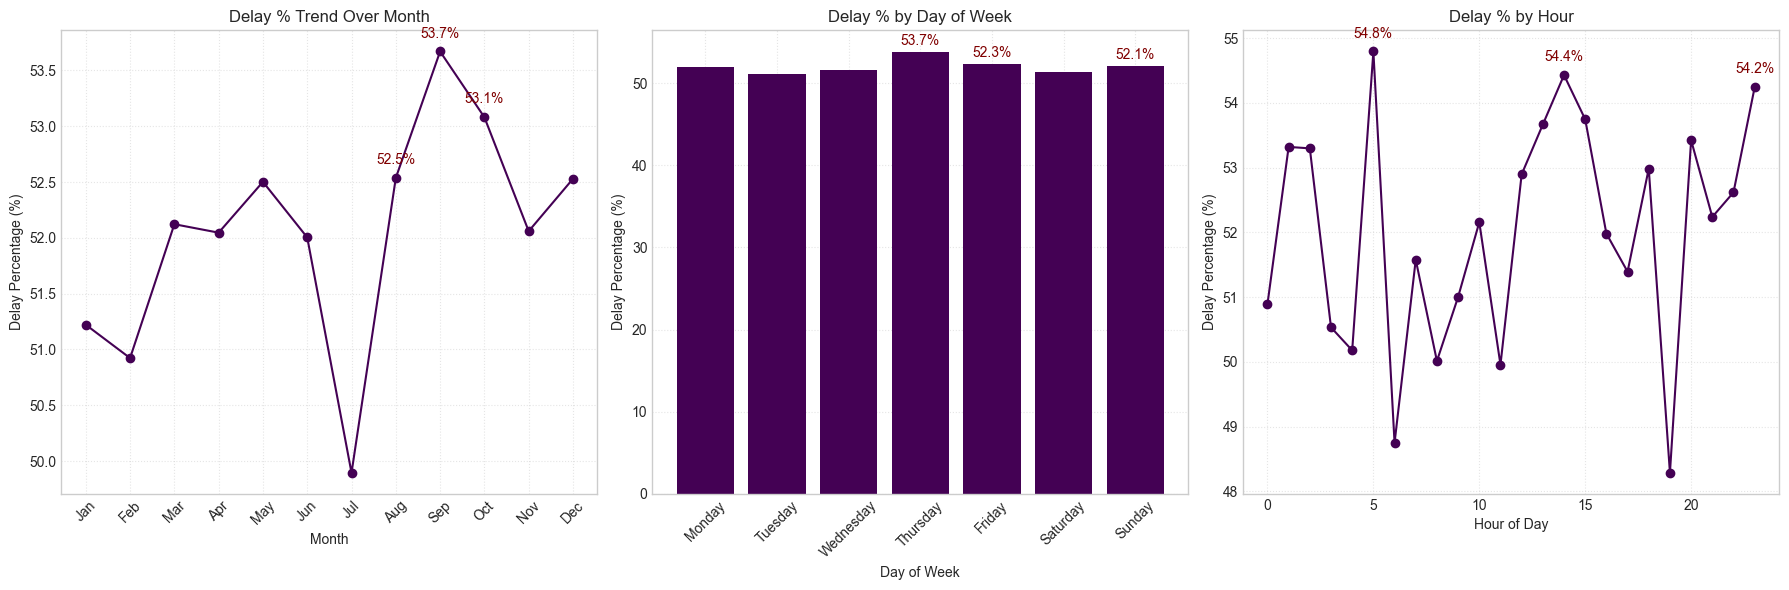

In [25]:
fig,(ax1,ax2,ax3) = plt.subplots(1,3,figsize=(18,6))

# Subplot 1: Delay % Trend Over Month
ax1.plot(delay_by_month['Order_month'], delay_by_month['delay_pct'], marker='o', color=primary_color)
ax1.set_xticks(range(1,13))
ax1.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
ax1.set_xlabel("Month")
ax1.set_ylabel("Delay Percentage (%)")
ax1.set_title("Delay % Trend Over Month")
ax1.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 highest
top3_month = delay_by_month. nlargest(3, 'delay_pct')
for _, row in top3_month.iterrows():
    ax1.annotate(f"{row['delay_pct'] :.1f}%", (row['Order_month'], row['delay_pct']),
        textcoords="offset points", xytext=(0,10), ha='center', fontsize=10, color=danger_color)

# Subplot 2: Delay % by Day of Week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
delay_by_day['Order_day'] = pd.Categorical(delay_by_day['Order_day'], categories=day_order, ordered=True)
delay_by_day = delay_by_day. sort_values('Order_day')

ax2.bar(delay_by_day['Order_day'], delay_by_day['delay_pct'], color=primary_color)
ax2.set_xticklabels(delay_by_day['Order_day'], rotation=45)
ax2.set_xlabel("Day of Week")
ax2.set_ylabel("Delay Percentage (%)")
ax2.set_title("Delay % by Day of Week")
ax2.grid(True, linestyle=':', alpha=0.5)
# Annotate top 3 highest bars
top3_day = delay_by_day.nlargest(3, 'delay_pct')
for _, row in top3_day.iterrows():
    height = row['delay_pct']
    ax2.text(row['Order_day'], height + 0.5, f'{height :.1f}%', ha='center', va='bottom', fontsize=10, color=danger_color)

# Subplot 3: Delay % by Hour
ax3.plot(delay_by_hour['Order_hour'], delay_by_hour['delay_pct'], marker='o', color=primary_color)
ax3.set_xlabel("Hour of Day")
ax3.set_ylabel("Delay Percentage (%)")
ax3.set_title("Delay % by Hour")
ax3.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 highest
top3_hour = delay_by_hour.nlargest(3, 'delay_pct')
for _, row in top3_hour. iterrows():
    ax3.annotate(f"{row['delay_pct'] :.1f}%", (row['Order_hour'], row['delay_pct']),
    textcoords="offset points", xytext=(0,10), ha='center', fontsize=10, color=danger_color)


plt.tight_layout()
plt.show()


